In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
ga1 = systemClasses.System(dataset=dataset, name="GA-1")
ga2 = systemClasses.System(dataset=dataset, name="GA-2")

Initializing GA-2 Sensors: 100%|██████████| 18/18 [00:04<00:00,  3.68sensor/s]


In [31]:
pressure1 = sensorClasses.Sensor(dataset=dataset, id=1011)
pressure2 = sensorClasses.Sensor(dataset=dataset, id=1012)
ambient_pressure = sensorClasses.Sensor(dataset=dataset, id=1038)
pump_pressure = sensorClasses.Sensor(dataset=dataset, id=1048)
lar_pressure1 = sensorClasses.Sensor(dataset=dataset, id=1050)
lar_pressure2 = sensorClasses.Sensor(dataset=dataset, id=1051)
lar_flow = sensorClasses.Sensor(dataset=dataset, id=1049)
level1 = sensorClasses.Sensor(dataset=dataset, id=1040)
level2 = sensorClasses.Sensor(dataset=dataset, id=1041)
# pressure1.data = pressure1.data.dropna()
# pressure2.data = pressure2.data.dropna()
# ambient_pressure.data = ambient_pressure.data.dropna()
# pump_pressure.data = pump_pressure.data.dropna()
# lar_pressure1.data = lar_pressure1.data.dropna()
# lar_pressure2.data = lar_pressure2.data.dropna()

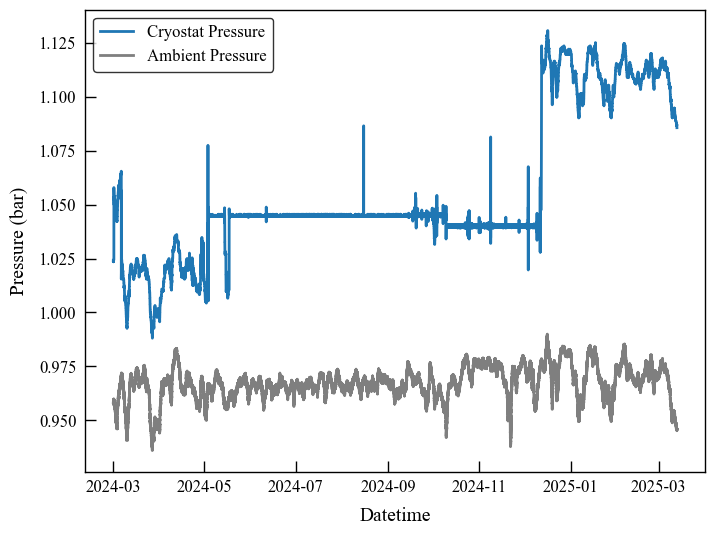

In [5]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, label="Cryostat Pressure", color="tab:blue")
# axes.plot(pressure2.data.index, pressure2.data.values, label="Pressure 2", color="tab:orange")
axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
# axes.plot(pump_pressure.data.index, pump_pressure.data.values, label="Pump Pressure", color="tab:red")
# axes.plot(lar_pressure1.data.index, lar_pressure1.data.values/1000, label="LAr Pressure 1", color="tab:green")
# axes.plot(lar_pressure2.data.index, lar_pressure2.data.values/1000,label="LAr Pressure 2", color="tab:purple")
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.legend()

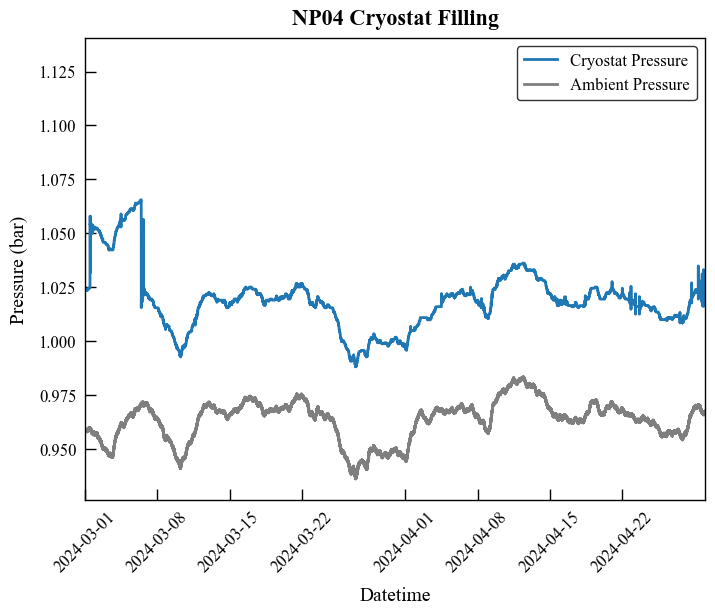

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, label="Cryostat Pressure", color="tab:blue")
axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-3-1 00:00:00"), pd.Timestamp("2024-4-30 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.tick_params(axis='x', rotation=45)
axes.set_title("NP04 Cryostat Filling")
axes.legend()

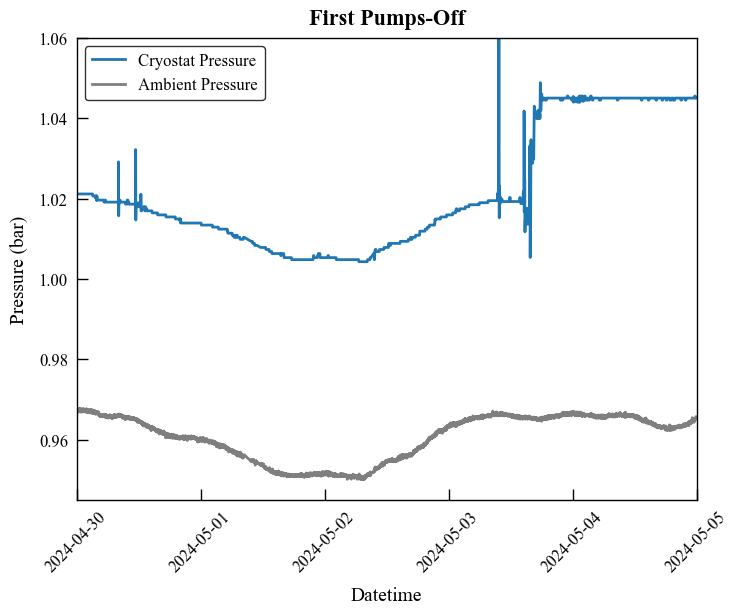

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, label="Cryostat Pressure", color="tab:blue")
axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-4-30 00:00:00"), pd.Timestamp("2024-5-05 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.tick_params(axis='x', rotation=45)
axes.set_title("First Pumps-Off")
axes.set_ylim(0.945, 1.06)
axes.legend()

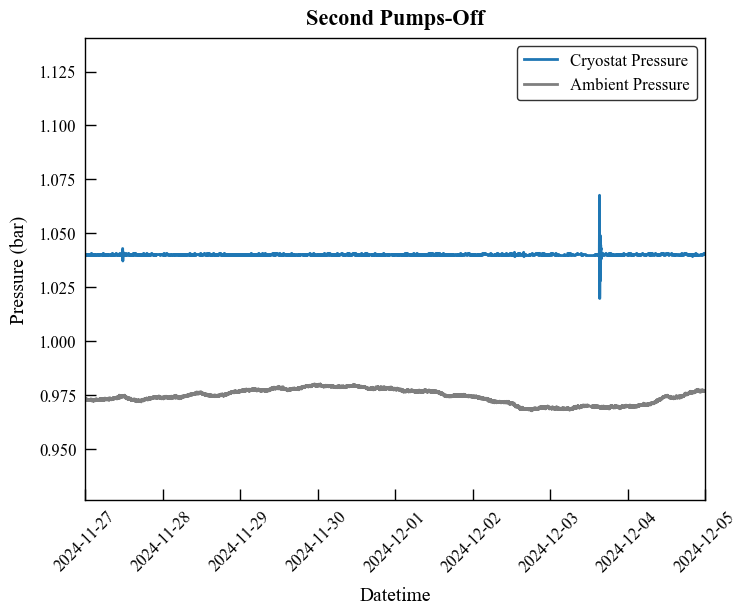

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, label="Cryostat Pressure", color="tab:blue")
axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-11-27 00:00:00"), pd.Timestamp("2024-12-05 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.tick_params(axis='x', rotation=45)
axes.set_title("Second Pumps-Off")
axes.legend()

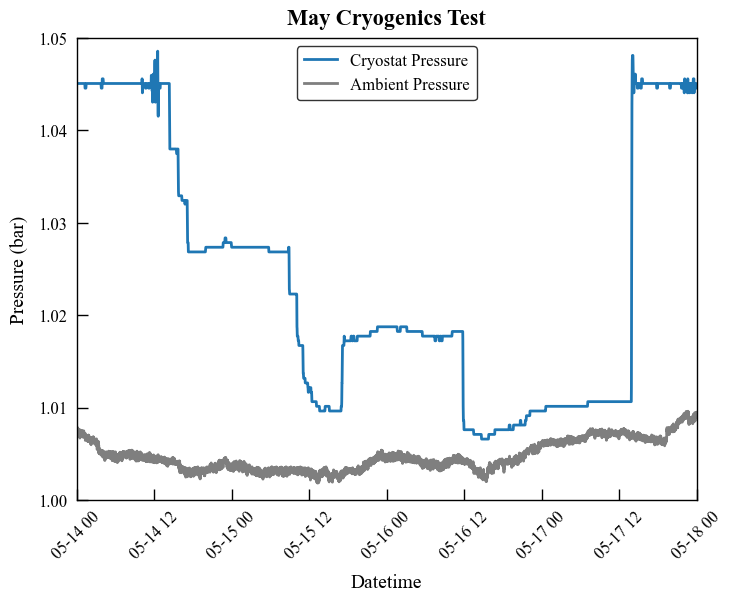

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, label="Cryostat Pressure", color="tab:blue")
axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000 + 0.047, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-5-14 00:00:00"), pd.Timestamp("2024-5-18 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.set_ylim(1.0, 1.05)
axes.tick_params(axis='x', rotation=45)
axes.set_title("May Cryogenics Test")
axes.legend()

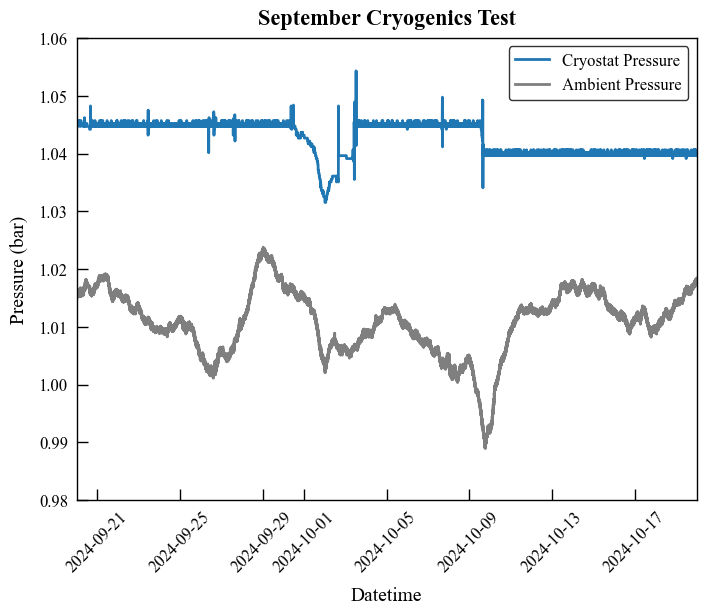

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, label="Cryostat Pressure", color="tab:blue")
axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000 + 0.047, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-9-20 00:00:00"), pd.Timestamp("2024-10-20 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.set_ylim(0.98, 1.06)
axes.tick_params(axis='x', rotation=45)
axes.set_title("September Cryogenics Test")
axes.legend()

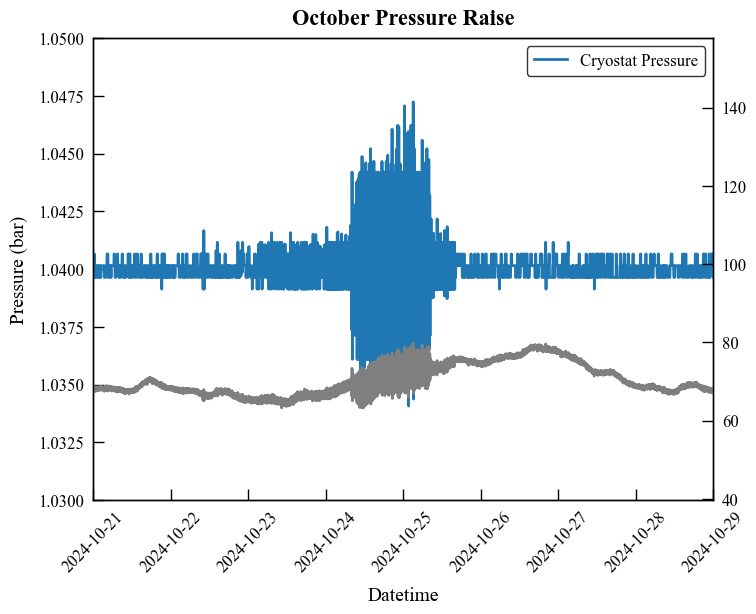

In [39]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, label="Cryostat Pressure", color="tab:blue")
axes2 = axes.twinx()
axes2.plot(lar_pressure1.data.index, lar_pressure1.data.values, label="Liquid Argon Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-10-21 00:00:00"), pd.Timestamp("2024-10-29 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.set_ylim(1.03, 1.05)
axes.tick_params(axis='x', rotation=45)
axes.set_title("October Pressure Raise")
axes.legend()

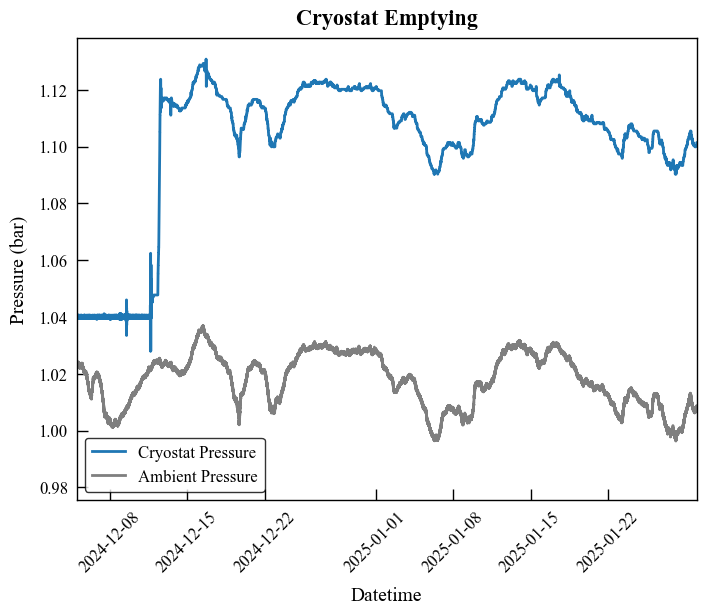

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, label="Cryostat Pressure", color="tab:blue")
axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000 + 0.047, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-12-5 00:00:00"), pd.Timestamp("2025-1-30 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
# axes.set_ylim(0.98, 1.06)
axes.tick_params(axis='x', rotation=45)
axes.set_title("Cryostat Emptying")
axes.legend()

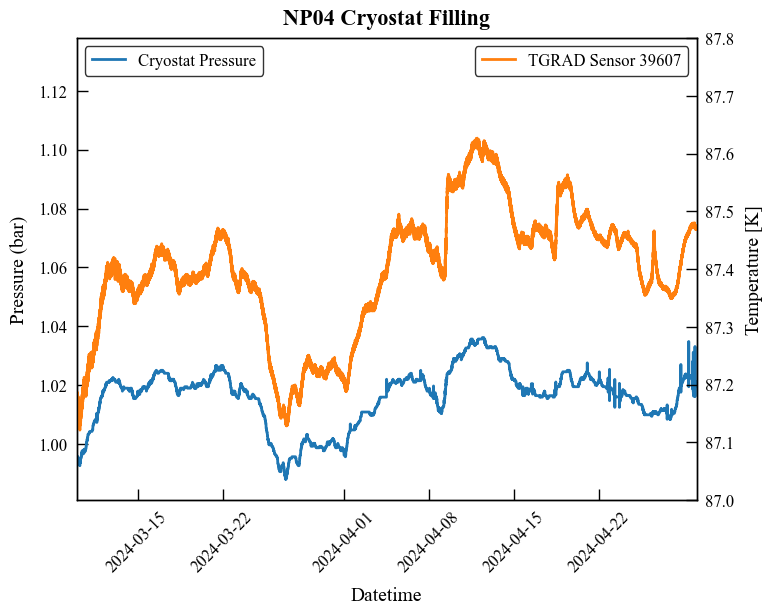

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, label="Cryostat Pressure", color="tab:blue")
# axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-3-10 00:00:00"), pd.Timestamp("2024-4-30 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.tick_params(axis='x', rotation=45)
axes.set_title("NP04 Cryostat Filling")
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, label="TGRAD Sensor 39607", color="tab:orange")
axes2.set_ylim(87,87.8)
axes2.set_ylabel("Temperature [K]")
axes2.legend(loc="upper right")

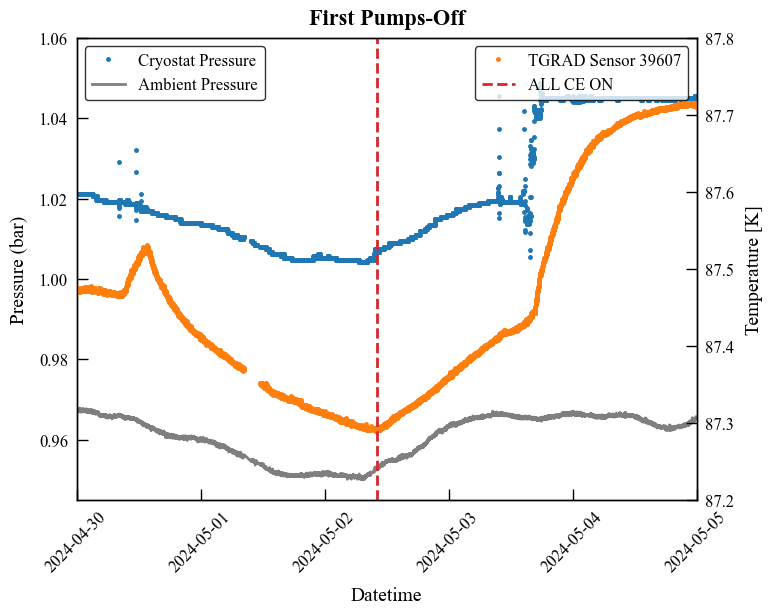

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:blue")
axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-4-30 00:00:00"), pd.Timestamp("2024-5-05 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.set_ylim(0.945, 1.06)
axes.tick_params(axis='x', rotation=45)
axes.set_title("First Pumps-Off")
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label="TGRAD Sensor 39607", color="tab:orange")
axes2.set_ylim(87.2,87.8)
axes2.set_ylabel("Temperature [K]")
axes2.axvline(pd.Timestamp("2024-05-02 10:08:00"), color="tab:red", linestyle="--", label="ALL CE ON")
axes2.legend(loc="upper right")

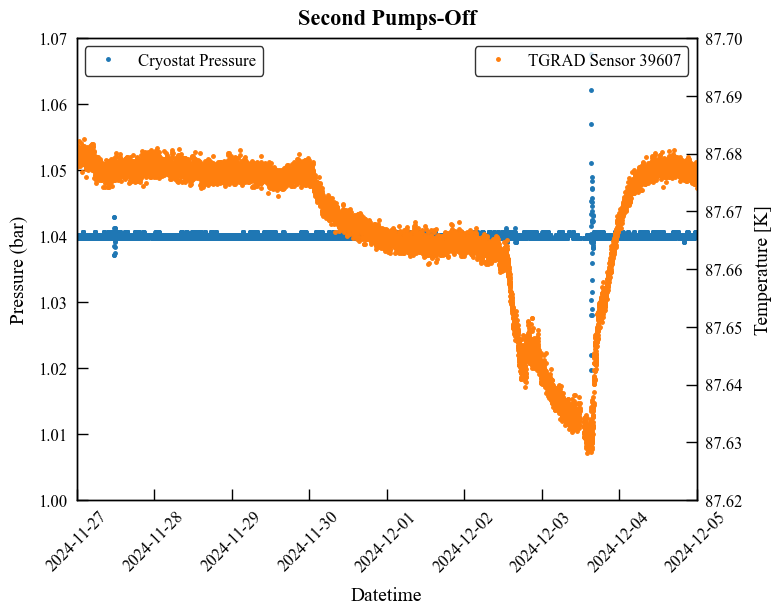

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:blue")
# axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-11-27 00:00:00"), pd.Timestamp("2024-12-05 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.set_ylim(1, 1.07)
axes.tick_params(axis='x', rotation=45)
axes.set_title("Second Pumps-Off")
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label="TGRAD Sensor 39607", color="tab:orange")
axes2.set_ylim(87.62,87.7)
axes2.set_ylabel("Temperature [K]")
axes2.legend(loc="upper right")

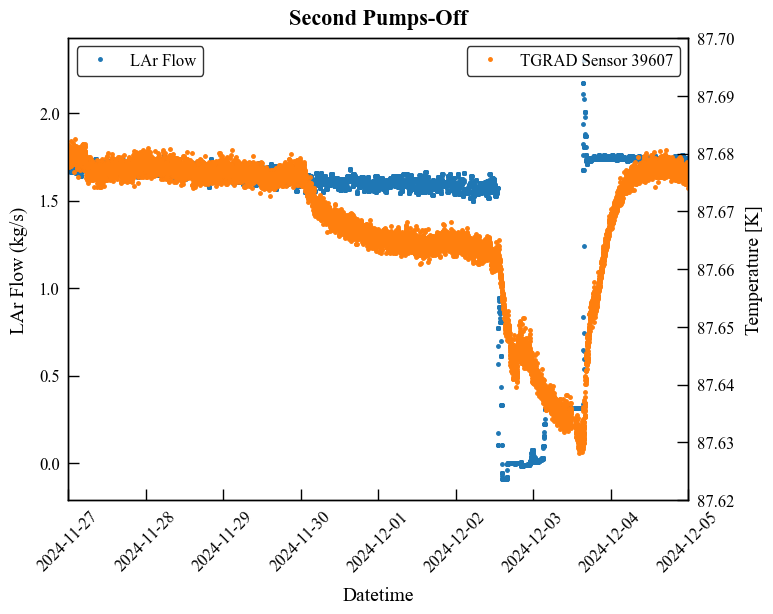

In [25]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(lar_flow.data.index, lar_flow.data.values, ".", label="LAr Flow", color="tab:blue")
# axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-11-27 00:00:00"), pd.Timestamp("2024-12-05 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("LAr Flow (kg/s)")
# axes.set_ylim(1, 1.07)
axes.tick_params(axis='x', rotation=45)
axes.set_title("Second Pumps-Off")
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label="TGRAD Sensor 39607", color="tab:orange")
axes2.set_ylim(87.62,87.7)
axes2.set_ylabel("Temperature [K]")
axes2.legend(loc="upper right")

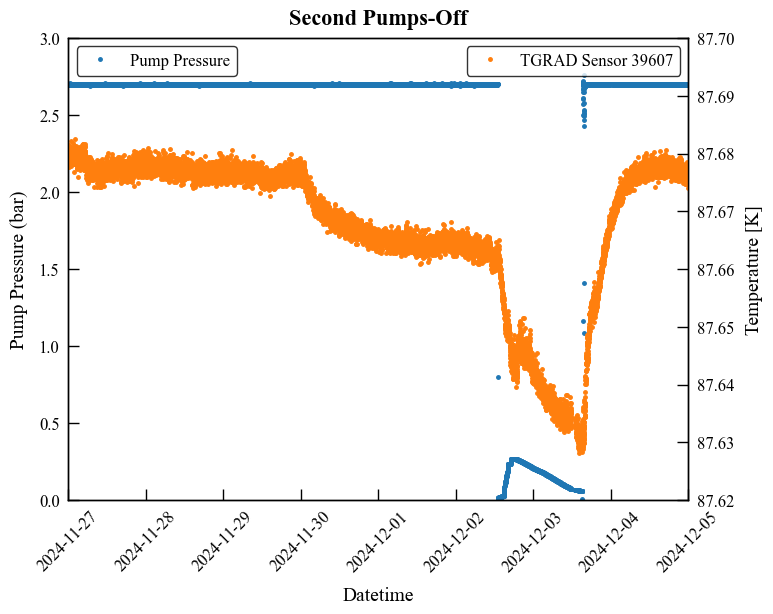

In [27]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pump_pressure.data.index, pump_pressure.data.values, ".", label="Pump Pressure", color="tab:blue")
# axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-11-27 00:00:00"), pd.Timestamp("2024-12-05 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pump Pressure (bar)")
axes.set_ylim(0, 3)
axes.tick_params(axis='x', rotation=45)
axes.set_title("Second Pumps-Off")
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label="TGRAD Sensor 39607", color="tab:orange")
axes2.set_ylim(87.62,87.7)
axes2.set_ylabel("Temperature [K]")
axes2.legend(loc="upper right")

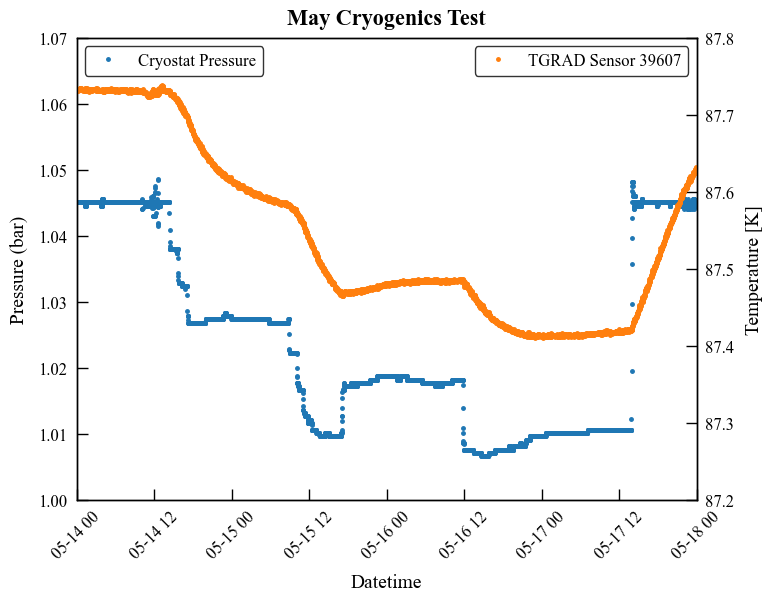

In [22]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:blue")
# axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-5-14 00:00:00"), pd.Timestamp("2024-5-18 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.set_ylim(1, 1.07)
axes.tick_params(axis='x', rotation=45)
axes.set_title("May Cryogenics Test")
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label="TGRAD Sensor 39607", color="tab:orange")
axes2.set_ylim(87.2,87.8)
axes2.set_ylabel("Temperature [K]")
axes2.legend(loc="upper right")

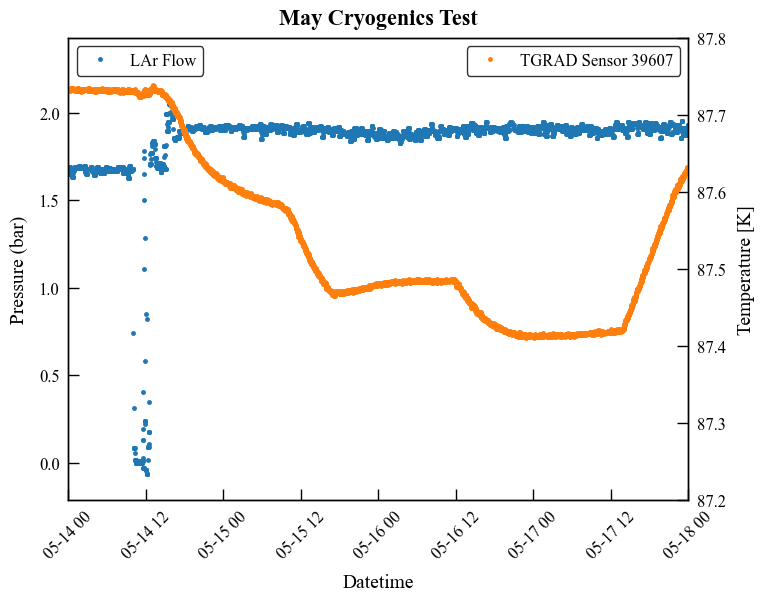

In [29]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(lar_flow.data.index, lar_flow.data.values, ".", label="LAr Flow", color="tab:blue")
# axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-5-14 00:00:00"), pd.Timestamp("2024-5-18 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
# axes.set_ylim(1, 1.07)
axes.tick_params(axis='x', rotation=45)
axes.set_title("May Cryogenics Test")
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label="TGRAD Sensor 39607", color="tab:orange")
axes2.set_ylim(87.2,87.8)
axes2.set_ylabel("Temperature [K]")
axes2.legend(loc="upper right")

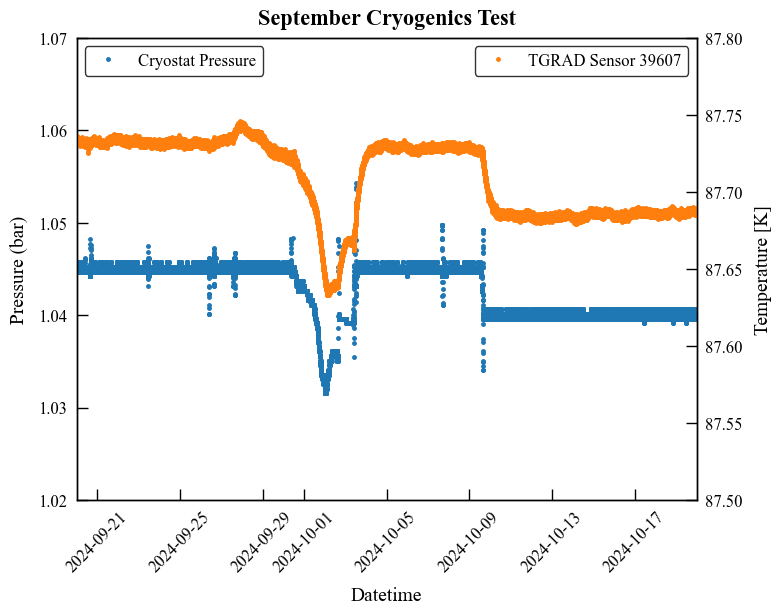

In [16]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:blue")
# axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-9-20 00:00:00"), pd.Timestamp("2024-10-20 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.set_ylim(1.02, 1.07)
axes.tick_params(axis='x', rotation=45)
axes.set_title("September Cryogenics Test")
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label="TGRAD Sensor 39607", color="tab:orange")
axes2.set_ylim(87.5,87.8)
axes2.set_ylabel("Temperature [K]")
axes2.legend(loc="upper right")

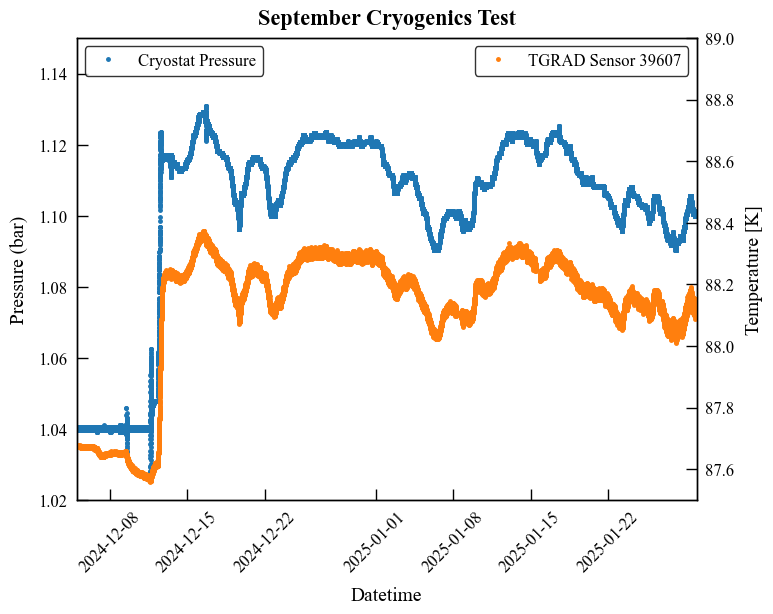

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:blue")
# axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-12-05 00:00:00"), pd.Timestamp("2025-01-30 00:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.set_ylim(1.02, 1.15)
axes.tick_params(axis='x', rotation=45)
axes.set_title("September Cryogenics Test")
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label="TGRAD Sensor 39607", color="tab:orange")
axes2.set_ylim(87.5,89)
axes2.set_ylabel("Temperature [K]")
axes2.legend(loc="upper right")

Text(0, 0.5, 'Temperature [K]')

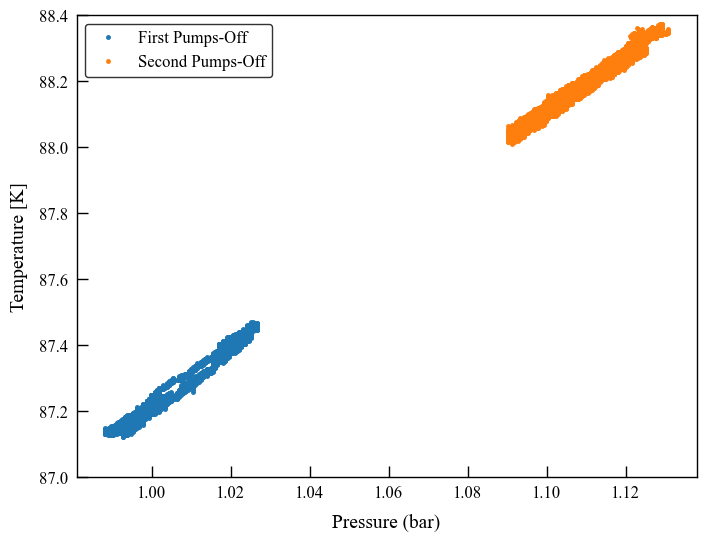

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(
     pressure1.data.loc[(pressure1.data.index > pd.Timestamp("2024-03-10 00:00:00")) &
                                  (pressure1.data.index < pd.Timestamp("2024-04-01 00:00:00"))].values,
     tgrad.sensors[39607].data.loc[(tgrad.sensors[39607].data.index > pd.Timestamp("2024-03-10 00:00:00")) &
                                  (tgrad.sensors[39607].data.index < pd.Timestamp("2024-04-01 00:00:00"))].values,
     ".", label="First Pumps-Off", color="tab:blue"
)
axes.plot(
     pressure1.data.loc[(pressure1.data.index > pd.Timestamp("2024-12-15 00:00:00")) &
                                  (pressure1.data.index < pd.Timestamp("2025-01-30 00:00:00"))].values,
     tgrad.sensors[39607].data.loc[(tgrad.sensors[39607].data.index > pd.Timestamp("2024-12-15 00:00:00")) &
                                  (tgrad.sensors[39607].data.index < pd.Timestamp("2025-01-30 00:00:00"))].values,
     ".", label="Second Pumps-Off", color="tab:orange"
)
axes.set_ylim(87, 88.4)
axes.legend()
axes.set_xlabel("Pressure (bar)")
axes.set_ylabel("Temperature [K]")

Fit parameters: [ 8.85489767 78.36479248]
Error on fit parameters: [0.00079082 0.00085393]


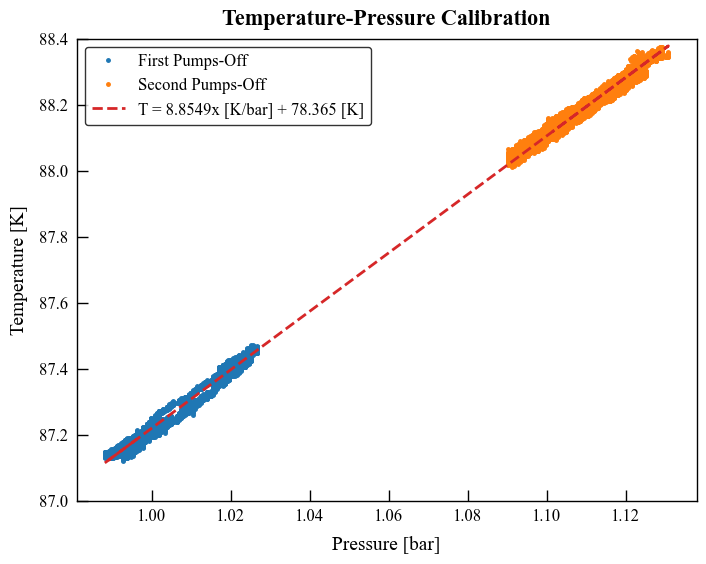

In [19]:
temp1 = tgrad.sensors[39607].data.loc[(tgrad.sensors[39607].data.index > pd.Timestamp("2024-03-10 00:00:00")) &
                                  (tgrad.sensors[39607].data.index < pd.Timestamp("2024-04-01 00:00:00"))]
temp2 = tgrad.sensors[39607].data.loc[(tgrad.sensors[39607].data.index > pd.Timestamp("2024-12-15 00:00:00")) &
                                  (tgrad.sensors[39607].data.index < pd.Timestamp("2025-01-30 00:00:00"))]
press1 = pressure1.data.loc[(pressure1.data.index > pd.Timestamp("2024-03-10 00:00:00")) &
                                  (pressure1.data.index < pd.Timestamp("2024-04-01 00:00:00"))]
press2 = pressure1.data.loc[(pressure1.data.index > pd.Timestamp("2024-12-15 00:00:00")) &
                                  (pressure1.data.index < pd.Timestamp("2025-01-30 00:00:00"))]
joint_press = pd.concat([press1, press2], axis=0)
joint_temp = pd.concat([temp1, temp2], axis=0)
joint = pd.concat([joint_press, joint_temp], axis=1)
joint.columns = ["press", "temp"]

joint = joint.loc[(joint.temp > 87.0) & (joint.temp < 88.4)]

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(press1.values, temp1.values, ".", label="First Pumps-Off", color="tab:blue")
axes.plot(press2.values, temp2.values, ".", label="Second Pumps-Off", color="tab:orange")
axes.set_xlabel("Pressure [bar]")
axes.set_ylabel("Temperature [K]")
axes.set_ylim(87, 88.4)

popt, pcov = np.polyfit(joint.press.values, joint.temp.values, 1, cov=True)
print(f"Fit parameters: {popt}")
print(f"Error on fit parameters: {np.sqrt(np.diag(pcov))}")
axes.plot(joint.press.values, np.polyval(popt, joint.press.values), "--", label=fr"T = {popt[0]:.4f}x [K/bar] + {popt[1]:.3f} [K]", color="tab:red")
axes.set_title("Temperature-Pressure Calibration")
axes.legend();


In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:blue")
# axes.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, label="Ambient Pressure", color="tab:gray")
axes.set_xlim(pd.Timestamp("2024-4-30 00:00:00"), pd.Timestamp("2024-5-03 12:00:00"))
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.set_ylim(1, 1.07)
axes.tick_params(axis='x', rotation=45)
axes.set_title("First Pumps-Off")
axes.legend(loc="upper left")
axes2 = axes.twinx()
# axes2.plot((tgrad.sensors[39607].data - popt[0]*pressure1.data).index, (tgrad.sensors[39607].data - popt[0]*pressure1.data).values, ".", label="TGRAD Sensor 39607", color="tab:orange")
axes2.set_ylim(78.35,78.44)
axes2.set_ylabel("Temperature [K]")
axes2.axvline(pd.Timestamp("2024-5-01 15:03:00"), color="tab:red", linestyle="--", label="LOWER CE ON")
axes2.axvline(pd.Timestamp("2024-5-01 17:03:00"), color="tab:orange", linestyle="--", label="UPPER CE ON")
axes2.axvline(pd.Timestamp("2024-5-01 19:03:00"), color="tab:purple", linestyle="--", label="ALL CE OFF")
axes2.axvline(pd.Timestamp("2024-5-02 10:00:00"), color="tab:green", linestyle="--", label="ALL CE ON")

corrected_temp = tgrad.sensors[39607].data - popt[0]*pressure1.data,

axes2.plot(corrected_temp.index, corrected_temp, ".", label="TGRAD Sensor 39607", color="tab:orange")
axes2.legend(loc="upper right")